## HSBC Time Series Analysis

## Introduction
This notebook performs a time series analysis of HSBC stock data.
The analysis begins with exploratory data analysis, followed by statistical modeling and forecasting with a focus on banking-sector behavior

### Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")

### Download HSBC Data

In [3]:
hsbc = yf.download("HSBC", start="2020-01-01", end="2025-01-01")
hsbc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HSBC,HSBC,HSBC,HSBC,HSBC
Date,,,,,
2020-01-02,27.528950,27.528950,27.326173,27.368126,2046900
2020-01-03,27.102419,27.221291,26.997535,27.011520,1694800
2020-01-06,27.011522,27.025507,26.766788,26.766788,1807500
2020-01-07,26.808737,26.843698,26.724829,26.759790,2638800
2020-01-08,26.745806,26.836707,26.501074,26.501074,2299600


In [5]:
hsbc.columns

MultiIndex([( 'Close', 'HSBC'),
            (  'High', 'HSBC'),
            (   'Low', 'HSBC'),
            (  'Open', 'HSBC'),
            ('Volume', 'HSBC')],
           names=['Price', 'Ticker'])

### HSBC Closing Price Series

In [6]:
hsbc_price = hsbc["Close"]["HSBC"]
hsbc_price.head()

Date
2020-01-02    27.528950
2020-01-03    27.102419
2020-01-06    27.011522
2020-01-07    26.808737
2020-01-08    26.745806
Name: HSBC, dtype: float64

Adjusted Close prices are used as they account for dividends and stock splits, making them more suitable for financial and banking analysis.

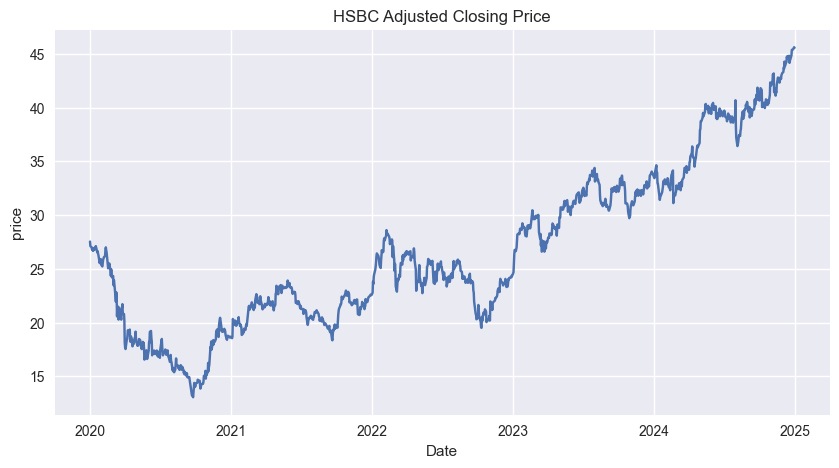

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(hsbc_price)
plt.title("HSBC Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("price")
plt.show()

### Observations
- HSBC prices show long-term stability consistent with a  large banking institution.
- Significant volatility is visible during the COVID-19 period.
- Price movements reflects sensitivity to macroeconomic conditions.

### Compute Daily Returns of HSBC Stock

In [8]:
hsbc_returns = hsbc_price.pct_change().dropna()
hsbc_returns.head()

Date
2020-01-03   -0.015494
2020-01-06   -0.003354
2020-01-07   -0.007507
2020-01-08   -0.002347
2020-01-09    0.006536
Name: HSBC, dtype: float64

Daily returns are used instead of prices because return series are more suitable for statistical modeling and financial risk analysis.

### Plot Returns

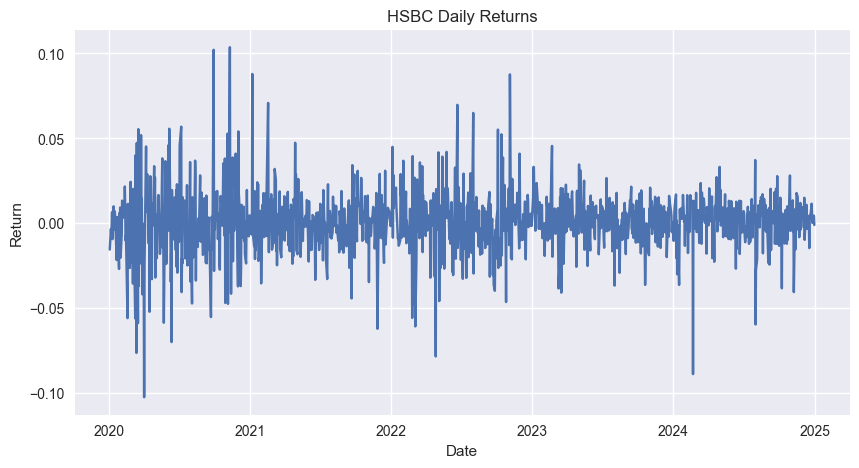

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(hsbc_returns)
plt.title("HSBC Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

### Observations
-Returns fluctuate around a mean close to zero.
-Volatility clustering is visible, especially during crisis periods.
Large spikes indicate periods of financial stress.

### Analyze Volatility

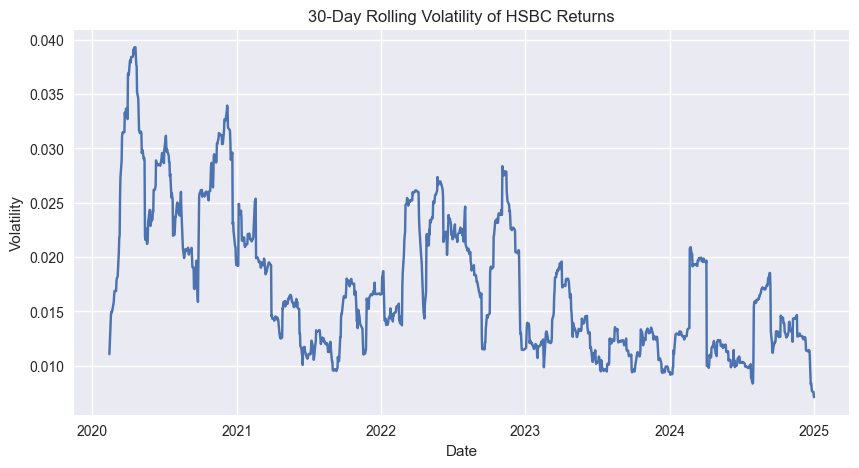

<Figure size 800x550 with 0 Axes>

In [11]:
rolling_volatility = hsbc_returns.rolling(window=30).std() 

plt.figure(figsize=(10, 5))
plt.plot(rolling_volatility)
plt.title("30-Day Rolling Volatility of HSBC Returns")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()
plt.savefig("hsbc_volatility.png", dpi=300, bbox_inches='tight')

Rolling Volatility highlights time-varying risk. Volatility increases during periods of economic uncertainty, which is typical behavior for banking stocks.

### Test Stationarity

In [14]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(hsbc_returns)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -11.154448460669306
p-value: 2.889248334048835e-20


### Interpretation of ADF Test Results
The Augmented Dickey-Fuller (ADF) Test was applied to the HSBC returns series to check whether the data is stationary.
The ADF statistics obtained is -11.18 and the p-value is extremely small (approximately 2.46 × 10⁻²⁰), which is far below the 0.05 significance level.
Therefore, we reject the null hypothesis of the presence of a unit root and conclude that the return series is stationary.
Since the return series is stationary, it satisfies the key assumption required for time series modeling using ARIMA. The data is now suitable for further analysis such as volatility modeling with GARCH.

Since the HSBC return series is stationary, ARIMA is applied directly to returns to model short-term dynamics.

A parsimonious ARIMA (1,0,1) model is selected because the returns series is already stationary,so no differencing is required (d=0). The AR(1) term captures short-term autocorrelation, while the MA(1) term accounts for shock corrections. This model balances interpretability and predictive performance without overfitting. 

In [2]:
import yfinance as yf
import numpy as np


In [10]:
hsbc = yf.download("HSBC", start="2020-01-01", end="2025-01-01")
hsbc_returns = np.log(hsbc["Close"]).diff().dropna()

[*********************100%***********************]  1 of 1 completed


In [11]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(hsbc_returns, order=(1, 0, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

                               SARIMAX Results                                
Dep. Variable:                   HSBC   No. Observations:                 1257
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3236.430
Date:                Wed, 15 Apr 2026   AIC                          -6464.860
Time:                        22:08:52   BIC                          -6444.315
Sample:                             0   HQIC                         -6457.139
                               - 1257                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      0.810      0.418      -0.001       0.001
ar.L1         -0.4812      0.178     -2.705      0.007      -0.830      -0.133
ma.L1          0.3944      0.187      2.110      0.0

### ARIMA Model Interpretation
-The AR(1) term captures short-term dependence in returns.
-The MA(1) term captures the impact of past shocks.
-Coefficient significance indicates whether past values contain predictive imformation.
-As expected for financial returns, predictive power is limited, which is typical in financial markets.

### Check Model Diagnostics

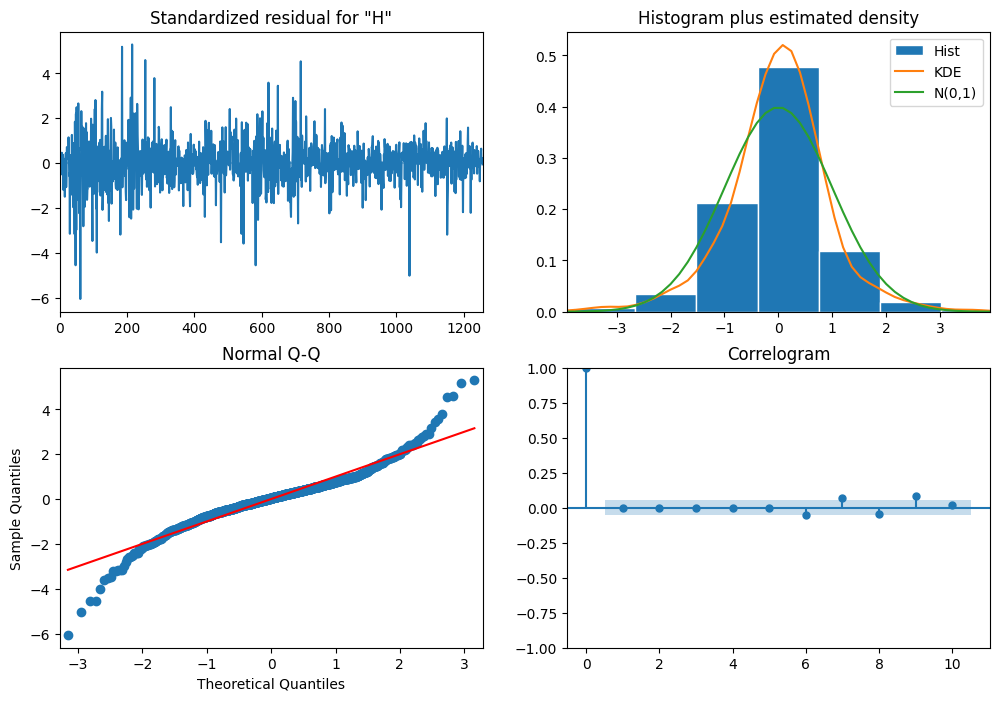

In [15]:
import matplotlib.pyplot as plot
arima_result.plot_diagnostics(figsize=(12, 8))
plot.show()

### Short Horizon Forecasting

In [16]:
forecast = arima_result.get_forecast(steps=20)
forecast

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Plot the Forecast

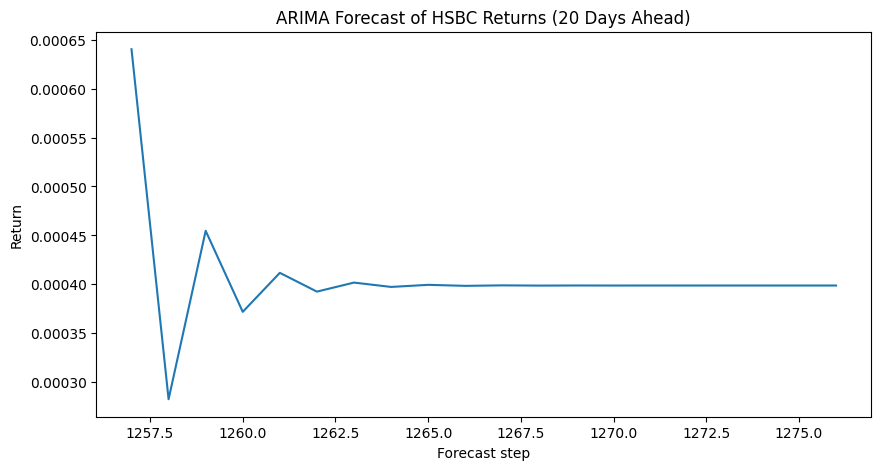

In [22]:
import matplotlib.pyplot as plt
forecast_values = forecast.predicted_mean
plt.figure(figsize=(10,5))
plt.plot(forecast_values)
plt.title("ARIMA Forecast of HSBC Returns (20 Days Ahead)")
plt.xlabel("Forecast step")
plt.ylabel("Return")
plt.show()


### ARIMA Forecast of HSBC Returns (20 Days Ahead)

The figure presents the 20-day ahead forecast of HSBC stock returns generated using the ARIMA model. At the beginning of the forecast period, the predicted returns show some short-term fluctuations, which reflect the model adjusting to recent patterns in the data. However, after a few forecast steps, the values gradually stabilize around a constant level.

This stabilization indicates that the model does not expect strong upward or downward movements in returns over the forecast horizon. Instead, it suggests that future returns are likely to remain close to their historical average.

Such behavior is typical when forecasting financial return series, since stock returns are usually volatile in the short term but tend to revert toward a stable mean over time. Overall, the ARIMA model suggests limited predictability in short-term HSBC return movements.

### Train-Test Evaluation


To evaluate the forecasting performance of the ARIMA model, the dataset is divided into training and testing subsets. The last 20 observations are reserved as the test set, while the remaining data is used to train the model.

This approach allows us to compare the model’s forecasts with actual observed returns and assess its predictive accuracy.

In [23]:
train = hsbc_returns[:-20]
test = hsbc_returns[-20:]

### Refit the ARIMA Model and Generate Forecast

After splitting the dataset into training and testing sets, the ARIMA(1,0,1) model is refitted using only the training data. This ensures that future values are not used during model estimation.

The fitted model is then used to generate forecasts for the next 20 observations, which correspond to the test dataset. These forecasts are later compared with the actual values to evaluate model performance.

In [30]:
model_train = ARIMA(train, order=(1, 0, 1))
model_train_fit = model_train.fit()

forecast_test = model_train_fit.forecast (steps=20)

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

### Forecast Accuracy Evaluation Using RMSE

To assess the performance of the ARIMA model, the Root Mean Squared Error (RMSE) is calculated between the predicted values and the actual test data.

RMSE measures the average magnitude of forecast errors. A lower RMSE value indicates better predictive accuracy and suggests that the model's forecasts are closer to the observed returns.

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(test, forecast_test))
rmse

np.float64(0.007309216077970746)

### ARIMA Model Specification
HSBC daily returns are modeled using an ARIMA (1,0,1) model.
The return series is stationary based on the ADF test, so no differencing is required.
A Parsimonious model is chosen to avoid overfitting.

### Residual Diagnostics

In [3]:
import yfinance as yf
import numpy as np
hsbc = yf.download("HSBC", start="2020-01-01", end="2025-01-01")
hsbc_returns = np.log(hsbc["Close"]).diff().dropna()

[*********************100%***********************]  1 of 1 completed


In [4]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(hsbc_returns, order=(1, 0, 1))
arima_result = arima_model.fit()

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g

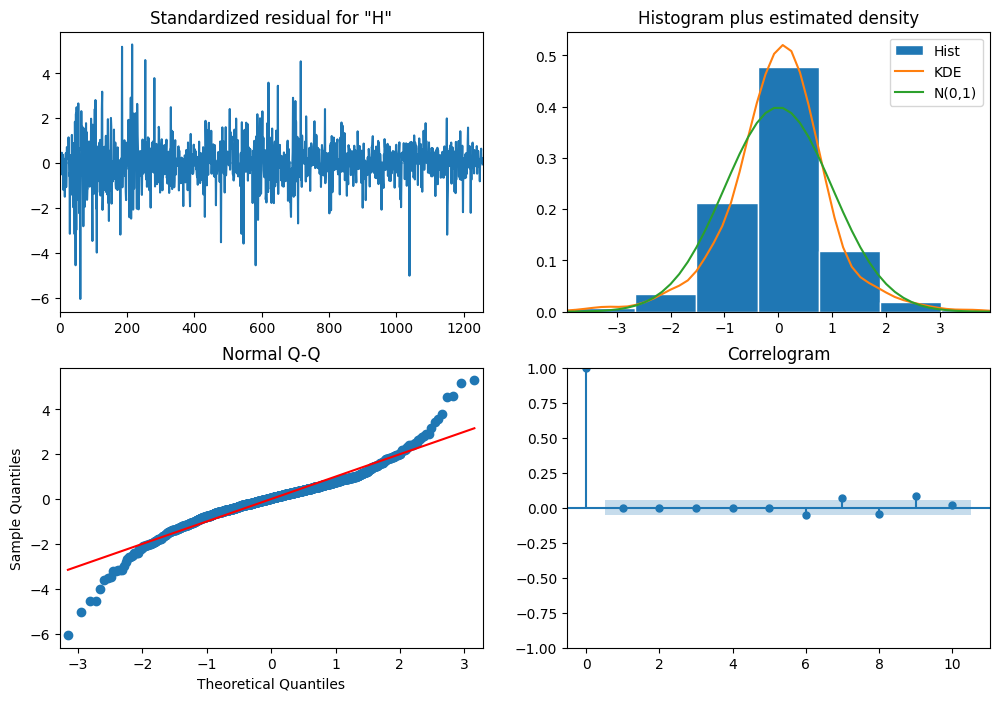

In [5]:
import matplotlib.pyplot as plt
arima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

### Residual Diagnostics Interpretation
The Residual fluctuate around zero with no clear systemetic patterns, suggesting that the ARIMA model captures most linear dependence in returns.
Some deviation from normality is observed, which is common in financial data.
Overall, residual behavior is consistent with White-Noise assumptions.

### Forecast Plausibility Check
This step assesses whether the ARIMA forecast behaves reasonably from a financial perspective. The Objective is not evaluate accuracy, but to verify that predicted returns follow expected financial properties such as stability, mean reversion and increasing uncertainty over time.

In [6]:
forecast = arima_result.get_forecast(steps=20)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


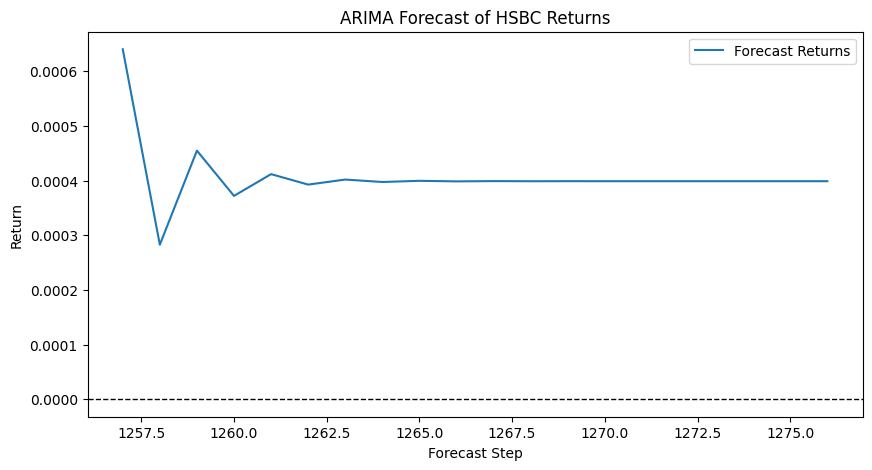

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_mean, label="Forecast Returns")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("ARIMA Forecast of HSBC Returns")
plt.xlabel("Forecast Step")
plt.ylabel("Return")
plt.legend()
plt.show()

### Forecast Interpretation
The forecasted returns oscillate around zero, indicating mean-reverting behavior.
There is no evidence of explosive or diverging forecasts, suggesting model stability.
This aligns with financial theory and the efficient market hypothesis for daily stock returns.


### Forecast Uncertainty
The widening confidence intervals indicate increasing uncertainty as the forecast horizon extends. This behavior is expected in financial forecasting and suggests that long-horizon predictions should be interpreted cautiously.

### Forecast Plausibility Assessment

Overall, the ARIMA forecast exhibits financially reasonable behavior: returns revert toward zero, forecasts remain stable, and uncertainty increases over time.
These characteristics indicate that the model is behaving appropriately as a baseline statistical model for financial returns.


## Volatility Modeling Using GARCH
Financial return series often exhibit volatility clustering, where periods of high volatility tend to be followed by high volatility and low volatility by low volatility. This behavior is especially important in banking-sector analysis, where understanding risk dynamics is more critical than predicting returns. To capture time-varying volatility, a GARCH model is applied to HSBC returns.

### Import the GARCH Library

In [9]:
from arch import arch_model

### Prepare the data

In [10]:
hsbc_returns_pct = hsbc_returns * 100

### Specify the GARCH Model

In [11]:
garch_model = arch_model(
    hsbc_returns_pct,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
    )
garch_results = garch_model.fit(disp="off")

In [12]:
print(garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   HSBC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -2481.86
Distribution:                  Normal   AIC:                           4969.71
Method:            Maximum Likelihood   BIC:                           4985.12
                                        No. Observations:                 1257
Date:                Tue, Apr 21 2026   Df Residuals:                     1257
Time:                        15:16:15   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0459  4.845e-02      0.947      0.344 

### GARCH Model Results Interpretation

The estimated GARCH(1,1) model provides insight into the volatility dynamics of HSBC returns.
- The **omega** parameter represents the long-run average level of volatility. Although not statistically significant, this is not uncommon in financial return series when volatility persistence is high.

- The **alpha(1)** coefficient captures the short-term impact of market shocks on volatility. A positive value indicates that new information affects volatility immediately.

- The **beta(1)** coefficient measures volatility persistence and is highly statistically significant. Its large magnitude indicates that volatility is strongly persistent, meaning periods of high volatility tend to cluster together over time.

Overall, the results confirm the presence of volatility clustering in HSBC returns, a well-documented characteristic of financial markets and an important consideration in banking-sector risk analysis.

### Plot Conditional Volatility

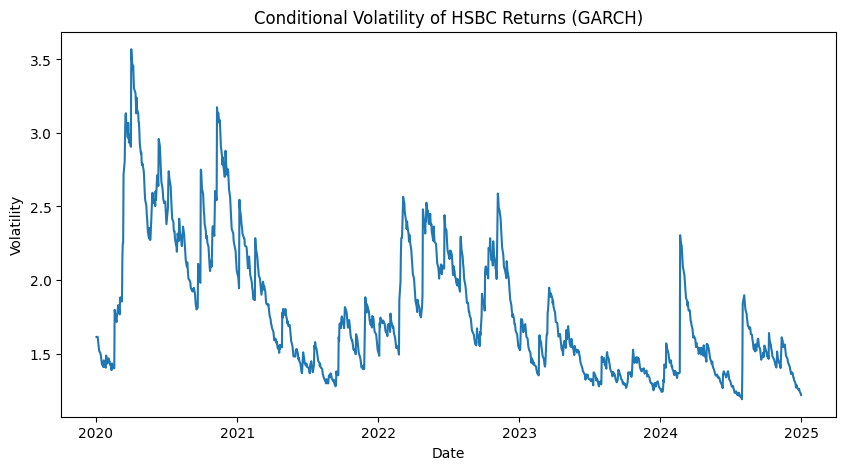

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(garch_results.conditional_volatility)
plt.title("Conditional Volatility of HSBC Returns (GARCH)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()


### Conditional Volatility Interpretation

The estimated conditional volatility displays clear evidence of volatility clustering, with extended periods of elevated volatility followed by calmer regimes. Notably, sharp volatility spikes are observed during periods of market stress, particularly around the COVID-19 crisis and subsequent macroeconomic uncertainty.


Over time, volatility gradually declines from crisis-driven peaks, indicating mean-reverting behavior in risk levels. This pattern confirms that volatility in HSBC returns is time-varying and persistent, a key characteristic of financial time series and a critical consideration for banking-sector risk management.



## Compare ARIMA vs GARCH

While the ARIMA model focuses on modeling return dynamics, the GARCH model provides insight into the evolution of risk over time. For banking applications, volatility modeling is often more informative than return forecasting.



## Limitations of GARCH

- GARCH assumes symmetric response to positive and negative shocks.
- It focuses solely on volatility and does not predict return direction.
- Sudden structural breaks may not be fully captured.


## Conclusion
- This project applied time series techniques to analyze the behavior of HSBC stock returns from a banking-sector perspective. ARIMA modeling was used to examine short-term returns dyanamics and confirmed that return predictability is limited, which is consistent with financial theory and market efficiency.
- In contrast, GARCH modeling revealed strong volatility persistence and clustering, highlighting that risk in banking stocks is time-varying and concentrated during periods of market stress. These findings emphasize that while return forecasts should be interpreted cautiously, volatility modeling provides valuable insight for risk assessment and financial decision making in banking institutions.